# Bank Marketing Campaign & Term Deposit Analytics

**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · PostgreSQL · SQL

## Project objective

This project analyzes customer and campaign behavior in a bank's direct-marketing dataset to understand which customer segments and campaign patterns are associated with term-deposit subscriptions.

The analysis focuses on four practical questions:

1. Which customer groups show stronger subscription rates?
2. Which campaign/contact patterns are associated with better outcomes?
3. Does repeated contact show signs of diminishing effectiveness?
4. How can these findings support better campaign planning?

> **Scope note:** This is a descriptive and diagnostic analytics project. It does not use machine learning. The `duration` variable is treated as a post-contact measure because it is observed during/after the call.

## 1. Setup and data loading

The first step is to load the raw data and establish the size, structure, and field names before making any analytical changes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv("../data/bank_marketing.csv")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head()

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-jv_h95r1 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Rows: 41,188
Columns: 21


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no


## 2. Data dictionary

The dataset contains customer profile attributes, campaign/contact history, macroeconomic indicators, and the final subscription outcome.

The target field is `y`:

- `yes` → customer subscribed to the term deposit
- `no` → customer did not subscribe

In [2]:
data_dictionary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null": df.notna().sum().values,
    "unique_values": df.nunique().values
})

data_dictionary

,column,dtype,non_null,unique_values
0,age,int64,41188,78
1,job,object,41188,12
2,marital,object,41188,4
3,education,object,41188,8
4,default,object,41188,3
5,housing,object,41188,3
6,loan,object,41188,3
7,contact,object,41188,2
8,month,object,41188,10
9,day_of_week,object,41188,5


## 3. Data quality assessment

In [3]:
quality = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
}).sort_values(["missing_values", "unique_values"], ascending=[False, True])

quality

,missing_values,missing_pct,unique_values
contact,0,0.00,2
y,0,0.00,2
default,0,0.00,3
housing,0,0.00,3
loan,0,0.00,3
poutcome,0,0.00,3
marital,0,0.00,4
day_of_week,0,0.00,5
education,0,0.00,8
previous,0,0.00,8


In [4]:
duplicate_count = df.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_count:,}")

if duplicate_count:
    df = df.drop_duplicates().reset_index(drop=True)

print(f"Rows after duplicate removal: {len(df):,}")

Exact duplicate rows: 12


Rows after duplicate removal: 41,176


In [5]:
unknown_summary = (
    df.astype("object")
      .apply(lambda s: s.eq("unknown").sum())
      .sort_values(ascending=False)
      .rename("unknown_count")
      .to_frame()
)

unknown_summary["unknown_pct"] = (
    unknown_summary["unknown_count"] / len(df) * 100
).round(2)

unknown_summary[unknown_summary["unknown_count"] > 0]

,unknown_count,unknown_pct
default,8596,20.88
education,1730,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


### Data-quality decisions

There are no conventional `NaN` values in the raw file, but several categorical fields use `unknown` as a value. These observations are retained rather than silently imputed because `unknown` is itself useful information about data completeness.

Exact duplicate rows are removed before the main analysis. In this dataset, 12 exact duplicate rows were found, leaving 41,176 analysis rows. No observations are removed solely because a value is unusual.

## 4. Overall subscription performance

In [6]:
target_summary = (
    df["y"].value_counts()
      .rename_axis("subscription")
      .reset_index(name="customers")
)

target_summary["share_pct"] = (
    target_summary["customers"] / len(df) * 100
).round(2)

target_summary

,subscription,customers,share_pct
0,no,36537,88.73
1,yes,4639,11.27


In [7]:
overall_rate = df["y"].eq("yes").mean() * 100
print(f"Overall subscription rate: {overall_rate:.2f}%")

Overall subscription rate: 11.27%


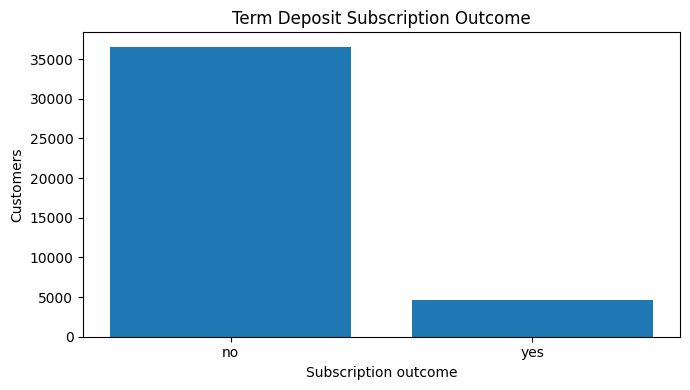

In [8]:
plt.figure(figsize=(7, 4))
counts = df["y"].value_counts().reindex(["no", "yes"])
plt.bar(counts.index, counts.values)
plt.title("Term Deposit Subscription Outcome")
plt.xlabel("Subscription outcome")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

The overall subscription rate is the baseline for the rest of the analysis. Segment rates should be interpreted alongside customer volume so that a small high-rate group is not mistaken for the largest business opportunity.

## 5. Reusable analysis function

In [9]:
def segment_summary(data, group_col, target="y"):
    out = (
        data.groupby(group_col, dropna=False, observed=False)[target]
            .agg(
                customers="size",
                subscribers=lambda s: s.eq("yes").sum()
            )
            .reset_index()
    )
    out["subscription_rate"] = (
        out["subscribers"] / out["customers"] * 100
    ).round(2)
    return out

## 6. Customer profile analysis

In [10]:
job_summary = segment_summary(df, "job").sort_values("subscription_rate", ascending=False)
job_summary

,job,customers,subscribers,subscription_rate
8,student,875,275,31.43
5,retired,1718,434,25.26
10,unemployed,1014,144,14.20
0,admin.,10419,1351,12.97
4,management,2924,328,11.22
11,unknown,330,37,11.21
9,technician,6739,730,10.83
6,self-employed,1421,149,10.49
3,housemaid,1060,106,10.00
2,entrepreneur,1456,124,8.52


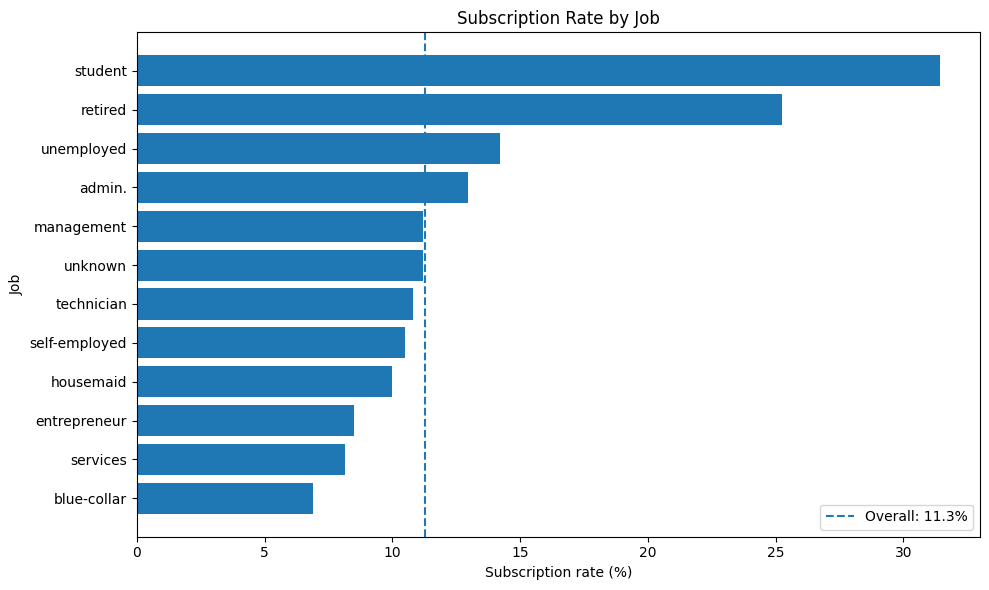

In [11]:
plt.figure(figsize=(10, 6))
plot_df = job_summary.sort_values("subscription_rate")
plt.barh(plot_df["job"], plot_df["subscription_rate"])
plt.axvline(overall_rate, linestyle="--", label=f"Overall: {overall_rate:.1f}%")
plt.title("Subscription Rate by Job")
plt.xlabel("Subscription rate (%)")
plt.ylabel("Job")
plt.legend()
plt.tight_layout()
plt.show()

Job groups differ materially in observed subscription rates. Student and retired customers are among the stronger-performing segments, while some larger working-professional groups sit closer to or below the overall benchmark. Because segment sizes differ, both rate and customer volume should be considered before prioritizing outreach.

In [12]:
age_bins = [-np.inf, 30, 40, 50, 60, np.inf]
age_labels = ["<=30", "31-40", "41-50", "51-60", "61+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels
)

age_summary = segment_summary(df, "age_group")
age_summary

,age_group,customers,subscribers,subscription_rate
0,<=30,7381,1124,15.23
1,31-40,16380,1597,9.75
2,41-50,10237,836,8.17
3,51-60,6269,668,10.66
4,61+,909,414,45.54


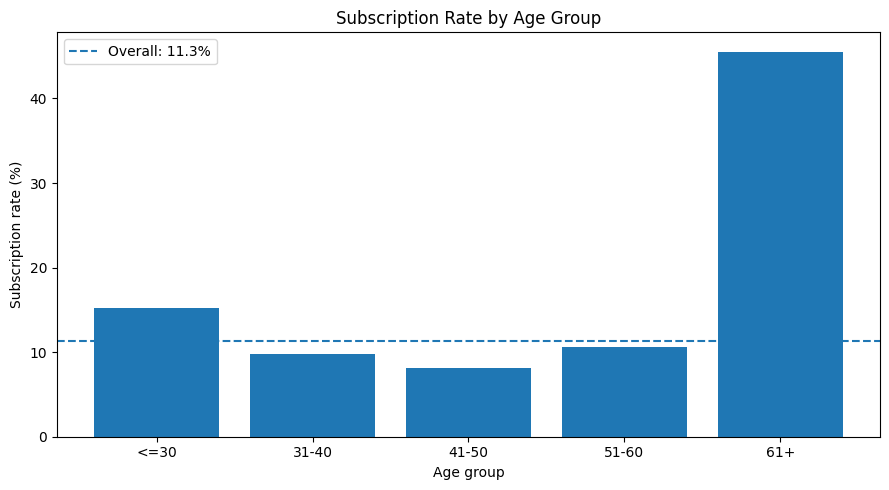

In [13]:
plt.figure(figsize=(9, 5))
plt.bar(age_summary["age_group"].astype(str), age_summary["subscription_rate"])
plt.axhline(overall_rate, linestyle="--", label=f"Overall: {overall_rate:.1f}%")
plt.title("Subscription Rate by Age Group")
plt.xlabel("Age group")
plt.ylabel("Subscription rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

The age pattern is not simply linear. The oldest segment has a noticeably stronger observed subscription rate, while the 31–50 groups are comparatively weaker. This is a descriptive relationship rather than evidence that age itself causes subscription behavior.

In [14]:
for col in ["education", "marital", "housing", "loan", "default"]:
    print(f"\n--- {col.upper()} ---")
    display(segment_summary(df, col).sort_values("subscription_rate", ascending=False))


--- EDUCATION ---


,education,customers,subscribers,subscription_rate
4,illiterate,18,4,22.22
7,unknown,1730,251,14.51
6,university.degree,12164,1669,13.72
5,professional.course,5240,595,11.35
3,high.school,9512,1031,10.84
0,basic.4y,4176,428,10.25
1,basic.6y,2291,188,8.21
2,basic.9y,6045,473,7.82



--- MARITAL ---


,marital,customers,subscribers,subscription_rate
3,unknown,80,12,15.00
2,single,11564,1620,14.01
0,divorced,4611,476,10.32
1,married,24921,2531,10.16



--- HOUSING ---


,housing,customers,subscribers,subscription_rate
2,yes,21571,2507,11.62
0,no,18615,2025,10.88
1,unknown,990,107,10.81



--- LOAN ---


,loan,customers,subscribers,subscription_rate
0,no,33938,3849,11.34
2,yes,6248,683,10.93
1,unknown,990,107,10.81



--- DEFAULT ---


,default,customers,subscribers,subscription_rate
0,no,32577,4196,12.88
1,unknown,8596,443,5.15
2,yes,3,0,0.00


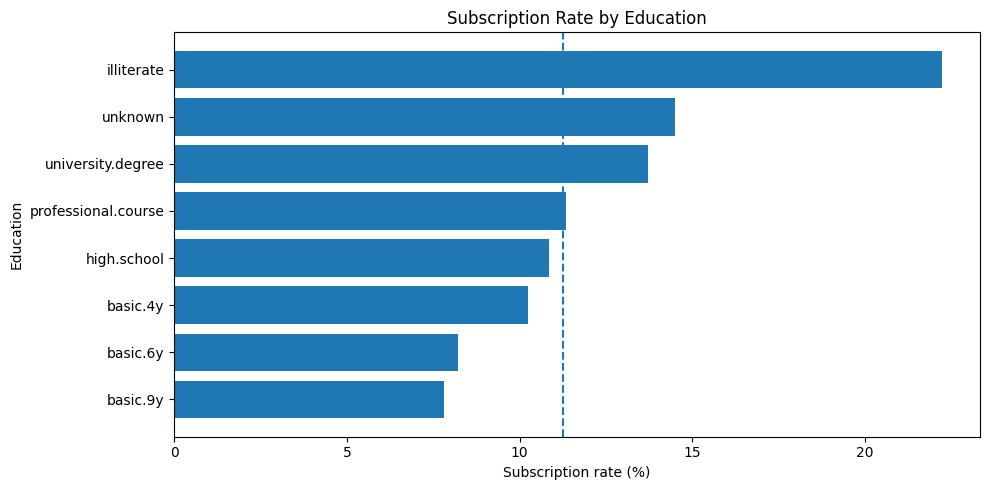

In [15]:
education_summary = segment_summary(df, "education").sort_values("subscription_rate")
plt.figure(figsize=(10, 5))
plt.barh(education_summary["education"], education_summary["subscription_rate"])
plt.axvline(overall_rate, linestyle="--")
plt.title("Subscription Rate by Education")
plt.xlabel("Subscription rate (%)")
plt.ylabel("Education")
plt.tight_layout()
plt.show()

Education shows some separation in subscription rates, with university-degree customers performing above several other large groups. Small categories should be interpreted cautiously because a high rate from a small population does not necessarily represent a large campaign opportunity.

## 7. Contact channel effectiveness

In [16]:
contact_summary = segment_summary(df, "contact").sort_values("subscription_rate", ascending=False)
contact_summary

,contact,customers,subscribers,subscription_rate
0,cellular,26135,3852,14.74
1,telephone,15041,787,5.23


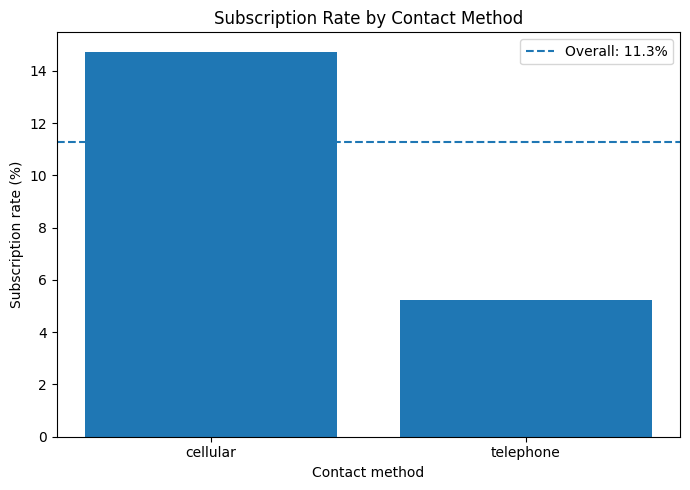

In [17]:
plt.figure(figsize=(7, 5))
plt.bar(contact_summary["contact"], contact_summary["subscription_rate"])
plt.axhline(overall_rate, linestyle="--", label=f"Overall: {overall_rate:.1f}%")
plt.title("Subscription Rate by Contact Method")
plt.xlabel("Contact method")
plt.ylabel("Subscription rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

Cellular contacts have a substantially higher observed subscription rate than telephone contacts. This is an association in the historical dataset, not proof that changing the contact method alone would produce the same lift in a future campaign.

## 8. Campaign frequency and contact fatigue

In [18]:
campaign_bins = [0, 2, 5, 10, np.inf]
campaign_labels = ["1-2 Contacts", "3-5 Contacts", "6-10 Contacts", "11+ Contacts"]

df["campaign_group"] = pd.cut(
    df["campaign"],
    bins=campaign_bins,
    labels=campaign_labels
)

campaign_summary = segment_summary(df, "campaign_group")
campaign_summary["campaign_group"] = pd.Categorical(
    campaign_summary["campaign_group"],
    categories=campaign_labels,
    ordered=True
)
campaign_summary = campaign_summary.sort_values("campaign_group")
campaign_summary

,campaign_group,customers,subscribers,subscription_rate
0,1-2 Contacts,28202,3510,12.45
1,3-5 Contacts,9589,943,9.83
2,6-10 Contacts,2516,159,6.32
3,11+ Contacts,869,27,3.11


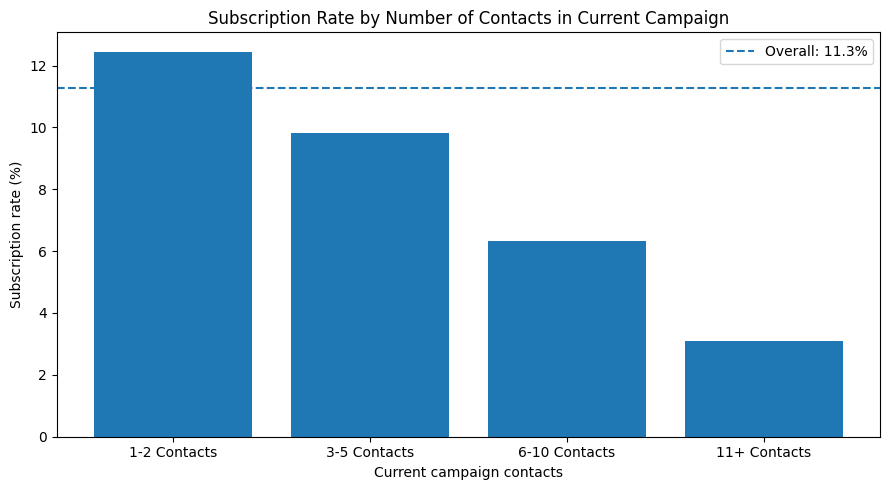

In [19]:
plt.figure(figsize=(9, 5))
plt.bar(campaign_summary["campaign_group"].astype(str), campaign_summary["subscription_rate"])
plt.axhline(overall_rate, linestyle="--", label=f"Overall: {overall_rate:.1f}%")
plt.title("Subscription Rate by Number of Contacts in Current Campaign")
plt.xlabel("Current campaign contacts")
plt.ylabel("Subscription rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

The observed subscription rate declines as the number of contacts increases. This is consistent with diminishing effectiveness at higher contact frequency, although the analysis is observational and cannot establish that repeated calls caused the lower response.

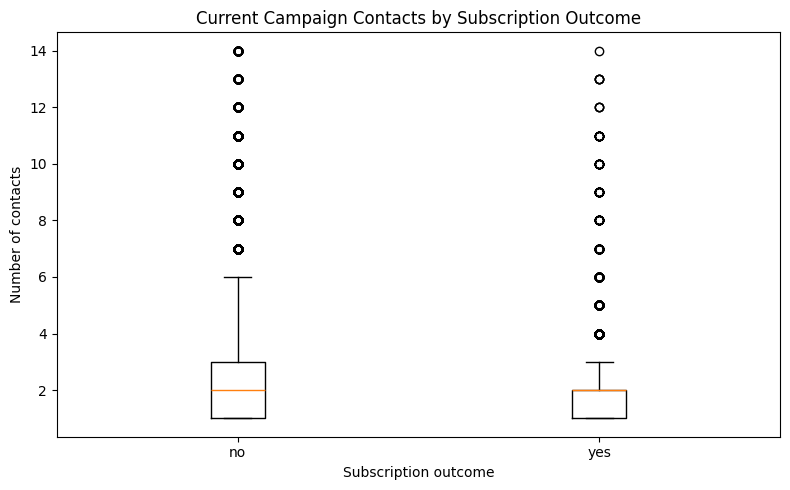

In [20]:
plt.figure(figsize=(8, 5))
box_data = [
    df.loc[df["y"].eq("no") & (df["campaign"] <= df["campaign"].quantile(0.99)), "campaign"],
    df.loc[df["y"].eq("yes") & (df["campaign"] <= df["campaign"].quantile(0.99)), "campaign"]
]
plt.boxplot(box_data, tick_labels=["no", "yes"])
plt.title("Current Campaign Contacts by Subscription Outcome")
plt.xlabel("Subscription outcome")
plt.ylabel("Number of contacts")
plt.tight_layout()
plt.show()

Subscribed customers tend to have fewer contacts in the current campaign. The boxplot complements the bucket analysis by showing the underlying spread rather than only four summary groups.

## 9. Previous campaign behavior

In [21]:
poutcome_summary = segment_summary(df, "poutcome").sort_values("subscription_rate", ascending=False)
poutcome_summary

,poutcome,customers,subscribers,subscription_rate
2,success,1373,894,65.11
0,failure,4252,605,14.23
1,nonexistent,35551,3140,8.83


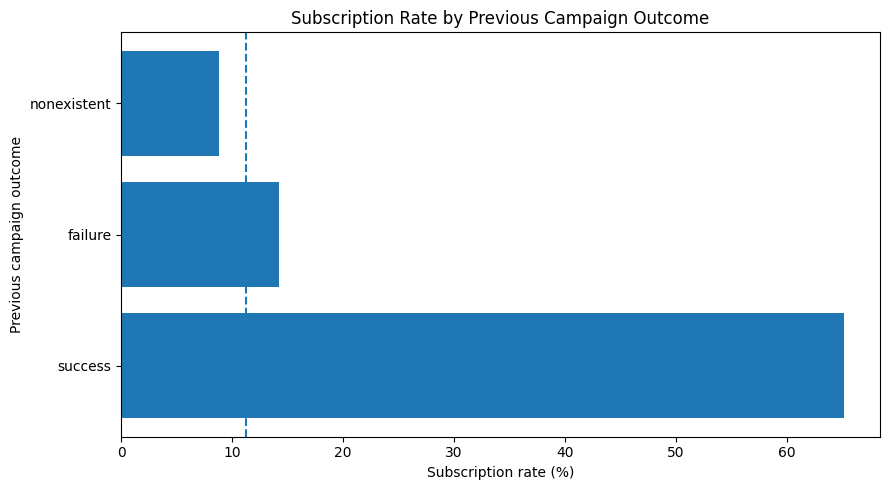

In [22]:
plt.figure(figsize=(9, 5))
plt.barh(poutcome_summary["poutcome"], poutcome_summary["subscription_rate"])
plt.axvline(overall_rate, linestyle="--")
plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Subscription rate (%)")
plt.ylabel("Previous campaign outcome")
plt.tight_layout()
plt.show()

Previous campaign outcome is one of the strongest behavioral separators in the dataset. Customers with a successful previous outcome have a much higher current subscription rate than customers with unsuccessful or nonexistent previous outcomes. This makes historical response a useful dimension for campaign planning.

In [23]:
df["had_prior_contact"] = np.where(
    df["pdays"].eq(999),
    "No prior contact",
    "Contacted before"
)

prior_contact_summary = segment_summary(df, "had_prior_contact")
prior_contact_summary

,had_prior_contact,customers,subscribers,subscription_rate
0,Contacted before,1515,967,63.83
1,No prior contact,39661,3672,9.26


## 10. Time-based campaign analysis

In [24]:
month_order = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]

month_summary = (
    segment_summary(df, "month")
    .set_index("month")
    .reindex(month_order)
    .reset_index()
)

month_summary

,month,customers,subscribers,subscription_rate
0,mar,546,276,50.55
1,apr,2631,539,20.49
2,may,13767,886,6.44
3,jun,5318,559,10.51
4,jul,7169,648,9.04
5,aug,6176,655,10.61
6,sep,570,256,44.91
7,oct,717,315,43.93
8,nov,4100,416,10.15
9,dec,182,89,48.90


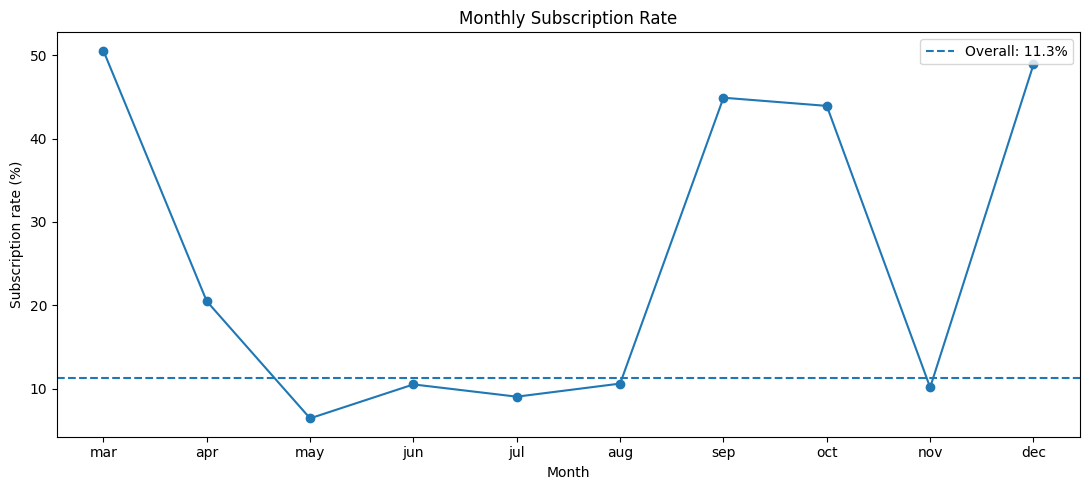

In [25]:
plt.figure(figsize=(11, 5))
plt.plot(month_summary["month"], month_summary["subscription_rate"], marker="o")
plt.axhline(overall_rate, linestyle="--", label=f"Overall: {overall_rate:.1f}%")
plt.title("Monthly Subscription Rate")
plt.xlabel("Month")
plt.ylabel("Subscription rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

Subscription rates vary considerably across months. These differences should be considered together with campaign volume and the composition of customers contacted in each month; the dataset alone does not establish that month timing caused the difference.

In [26]:
weekday_order = ["mon", "tue", "wed", "thu", "fri"]

weekday_summary = (
    segment_summary(df, "day_of_week")
    .set_index("day_of_week")
    .reindex(weekday_order)
    .reset_index()
)

weekday_summary

,day_of_week,customers,subscribers,subscription_rate
0,mon,8512,847,9.95
1,tue,8086,953,11.79
2,wed,8134,949,11.67
3,thu,8618,1044,12.11
4,fri,7826,846,10.81


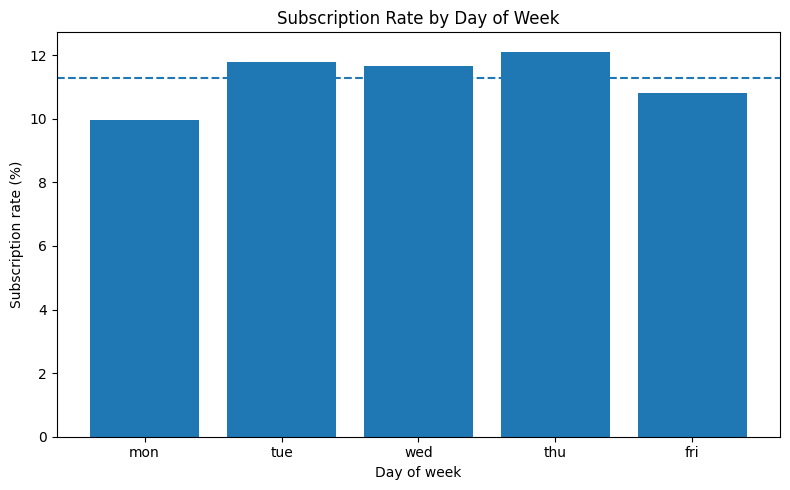

In [27]:
plt.figure(figsize=(8, 5))
plt.bar(weekday_summary["day_of_week"], weekday_summary["subscription_rate"])
plt.axhline(overall_rate, linestyle="--")
plt.title("Subscription Rate by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Subscription rate (%)")
plt.tight_layout()
plt.show()

Weekday differences are smaller than the gaps observed across some customer and campaign dimensions. This makes day-of-week a secondary planning consideration rather than the main segmentation lever.

## 11. Call duration — post-contact analysis

In [28]:
duration_bins = [-1, 300, 600, np.inf]
duration_labels = ["<=5 min", "5-10 min", ">10 min"]

df["duration_group"] = pd.cut(
    df["duration"],
    bins=duration_bins,
    labels=duration_labels
)

duration_summary = segment_summary(df, "duration_group")
duration_summary

,duration_group,customers,subscribers,subscription_rate
0,<=5 min,29974,1517,5.06
1,5-10 min,7738,1438,18.58
2,>10 min,3464,1684,48.61


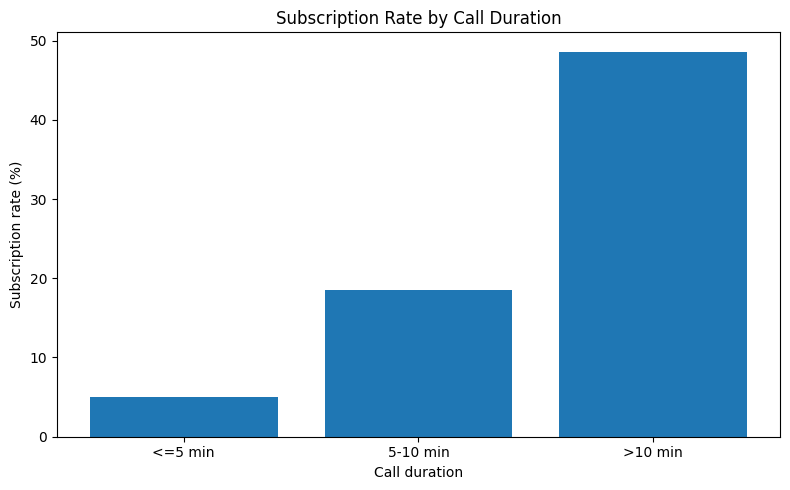

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(duration_summary["duration_group"].astype(str), duration_summary["subscription_rate"])
plt.title("Subscription Rate by Call Duration")
plt.xlabel("Call duration")
plt.ylabel("Subscription rate (%)")
plt.tight_layout()
plt.show()

Longer calls are associated with higher subscription rates in the observed data. This variable should be treated as a **post-contact indicator**, not as a pre-contact targeting recommendation, because duration is only known once the interaction has occurred.

## 12. Combined segment analysis

In [30]:
segment_combo = (
    df.groupby(["campaign_group", "poutcome"], observed=False)["y"]
      .agg(
          customers="size",
          subscribers=lambda s: s.eq("yes").sum()
      )
      .reset_index()
)

segment_combo["subscription_rate"] = (
    segment_combo["subscribers"] / segment_combo["customers"] * 100
).round(2)

segment_combo

,campaign_group,poutcome,customers,subscribers,subscription_rate
0,1-2 Contacts,failure,3307,478.00,14.45
1,1-2 Contacts,nonexistent,23771,"2,284.00",9.61
2,1-2 Contacts,success,1124,748.00,66.55
3,3-5 Contacts,failure,764,116.00,15.18
4,3-5 Contacts,nonexistent,8607,693.00,8.05
5,3-5 Contacts,success,218,134.00,61.47
6,6-10 Contacts,failure,172,11.00,6.40
7,6-10 Contacts,nonexistent,2313,136.00,5.88
8,6-10 Contacts,success,31,12.00,38.71
9,11+ Contacts,failure,9,0.00,0.00


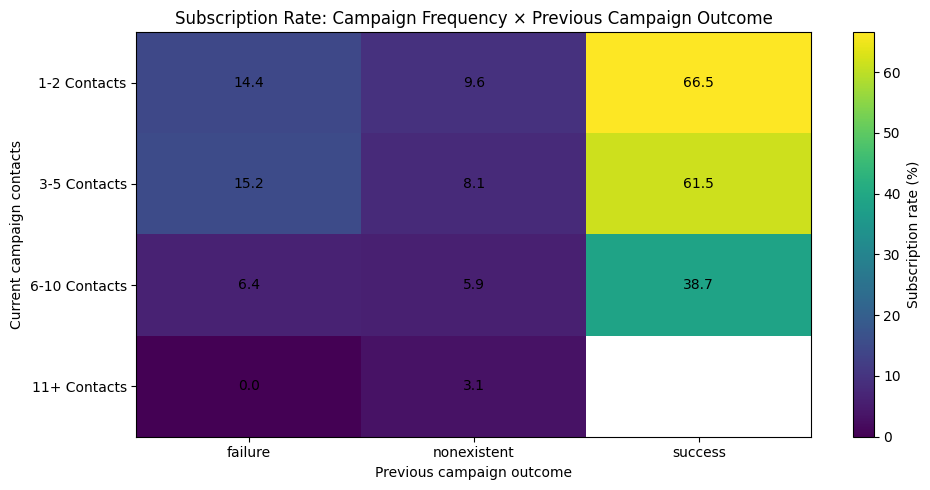

In [31]:
pivot_rate = segment_combo.pivot(
    index="campaign_group",
    columns="poutcome",
    values="subscription_rate"
).reindex(campaign_labels)

plt.figure(figsize=(10, 5))
plt.imshow(pivot_rate.values, aspect="auto")
plt.xticks(range(len(pivot_rate.columns)), pivot_rate.columns)
plt.yticks(range(len(pivot_rate.index)), pivot_rate.index.astype(str))
plt.colorbar(label="Subscription rate (%)")
for i in range(pivot_rate.shape[0]):
    for j in range(pivot_rate.shape[1]):
        value = pivot_rate.iloc[i, j]
        if pd.notna(value):
            plt.text(j, i, f"{value:.1f}", ha="center", va="center")
plt.title("Subscription Rate: Campaign Frequency × Previous Campaign Outcome")
plt.xlabel("Previous campaign outcome")
plt.ylabel("Current campaign contacts")
plt.tight_layout()
plt.show()

The combined view shows that previous campaign outcome continues to separate performance within campaign-frequency groups. Looking at both dimensions together is more useful for campaign planning than relying on either variable alone.

## 13. High-volume vs high-conversion opportunities

In [32]:
job_opportunity = job_summary.copy()
job_opportunity["rate_vs_overall_pp"] = (
    job_opportunity["subscription_rate"] - overall_rate
).round(2)

job_opportunity["opportunity_type"] = np.select(
    [
        (job_opportunity["customers"] >= job_opportunity["customers"].median()) &
        (job_opportunity["subscription_rate"] >= overall_rate),
        (job_opportunity["customers"] >= job_opportunity["customers"].median()) &
        (job_opportunity["subscription_rate"] < overall_rate),
        (job_opportunity["customers"] < job_opportunity["customers"].median()) &
        (job_opportunity["subscription_rate"] >= overall_rate)
    ],
    [
        "High volume / high rate",
        "High volume / low rate",
        "Lower volume / high rate"
    ],
    default="Lower volume / lower rate"
)

job_opportunity.sort_values(
    ["opportunity_type", "subscription_rate"],
    ascending=[True, False]
)

,job,customers,subscribers,subscription_rate,rate_vs_overall_pp,opportunity_type
5,retired,1718,434,25.26,13.99,High volume / high rate
0,admin.,10419,1351,12.97,1.70,High volume / high rate
4,management,2924,328,11.22,-0.05,High volume / low rate
9,technician,6739,730,10.83,-0.44,High volume / low rate
7,services,3967,323,8.14,-3.13,High volume / low rate
1,blue-collar,9253,638,6.90,-4.37,High volume / low rate
8,student,875,275,31.43,20.16,Lower volume / high rate
10,unemployed,1014,144,14.20,2.93,Lower volume / high rate
11,unknown,330,37,11.21,-0.06,Lower volume / lower rate
6,self-employed,1421,149,10.49,-0.78,Lower volume / lower rate


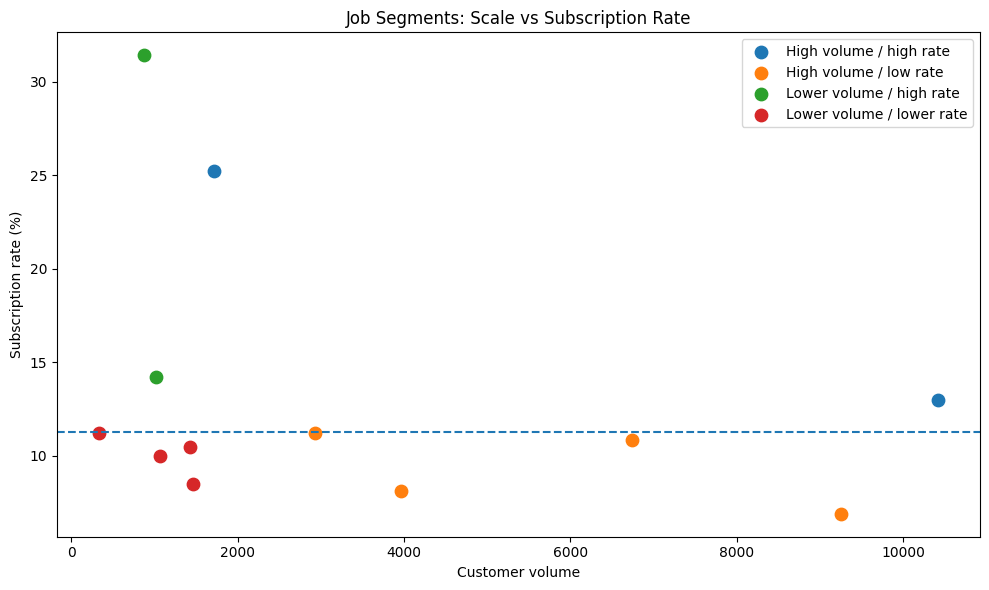

In [33]:
plt.figure(figsize=(10, 6))
for opportunity_type, group in job_opportunity.groupby("opportunity_type"):
    plt.scatter(group["customers"], group["subscription_rate"], label=opportunity_type, s=80)
plt.axhline(overall_rate, linestyle="--")
plt.xlabel("Customer volume")
plt.ylabel("Subscription rate (%)")
plt.title("Job Segments: Scale vs Subscription Rate")
plt.legend()
plt.tight_layout()
plt.show()

This view separates **rate** from **scale**. A small segment can have an excellent subscription rate without contributing many total subscribers, while a large segment with a weak rate may represent a more important optimization opportunity.

## 14. Numerical relationship check

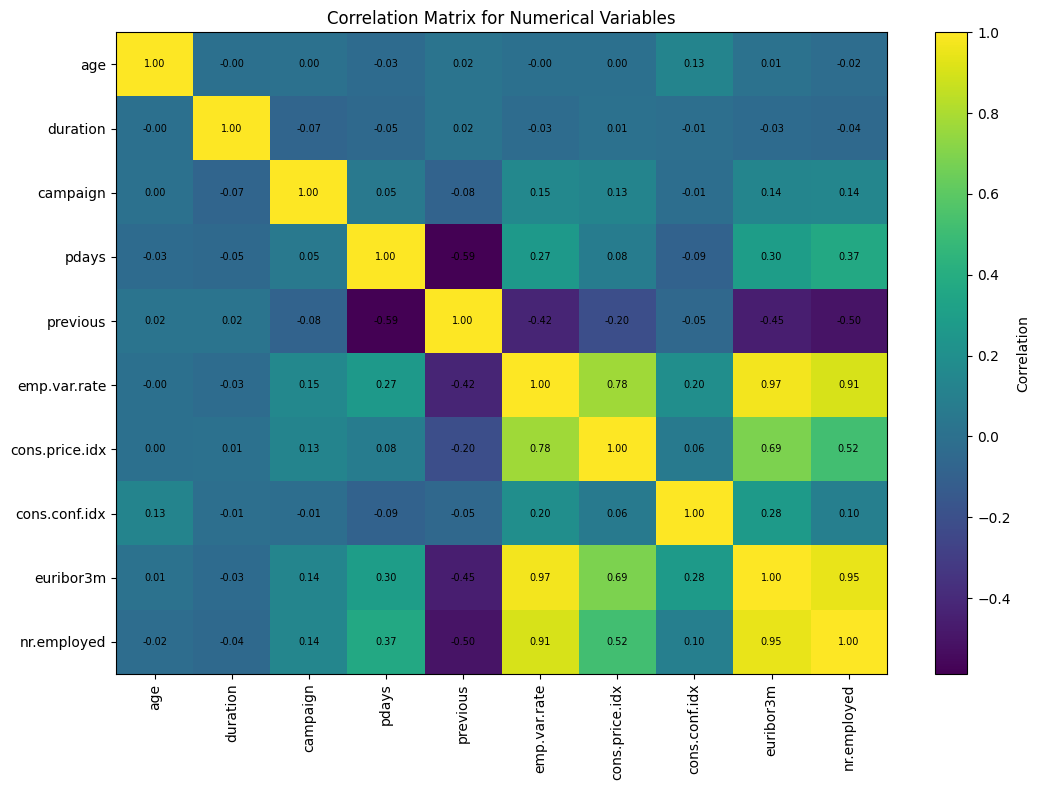

In [34]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 8))
plt.imshow(corr.values, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(label="Correlation")
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.title("Correlation Matrix for Numerical Variables")
plt.tight_layout()
plt.show()

The correlation matrix is used only as a descriptive diagnostic. Correlation does not establish causation, and categorical campaign variables require the segment analyses above rather than a simple correlation coefficient.

## 15. Key business insights

In [35]:
# Produce a compact evidence table that can be used to verify the final write-up.
top_job = job_summary.iloc[0]
top_age = age_summary.sort_values("subscription_rate", ascending=False).iloc[0]
top_contact = contact_summary.iloc[0]
best_poutcome = poutcome_summary.iloc[0]
best_campaign = campaign_summary.sort_values("subscription_rate", ascending=False).iloc[0]

insight_evidence = pd.DataFrame([
    ["Overall subscription rate", overall_rate],
    ["Highest-rate job", top_job["job"], top_job["subscription_rate"]],
    ["Highest-rate age group", str(top_age["age_group"]), top_age["subscription_rate"]],
    ["Highest-rate contact method", top_contact["contact"], top_contact["subscription_rate"]],
    ["Highest-rate previous outcome", best_poutcome["poutcome"], best_poutcome["subscription_rate"]],
    ["Highest-rate campaign bucket", str(best_campaign["campaign_group"]), best_campaign["subscription_rate"]],
], columns=["metric", "category", "value"])

insight_evidence

,metric,category,value
0,Overall subscription rate,11.27,NaN
1,Highest-rate job,student,31.43
2,Highest-rate age group,61+,45.54
3,Highest-rate contact method,cellular,14.74
4,Highest-rate previous outcome,success,65.11
5,Highest-rate campaign bucket,1-2 Contacts,12.45


### Summary of findings

1. **Subscription is relatively uncommon overall**, so conversion rate is more informative than raw subscriber counts for comparing segments.
2. **Previous campaign outcome is a strong differentiator**: customers with a successful previous outcome have a substantially higher observed subscription rate.
3. **Contact method matters descriptively**: cellular contacts show a much higher observed subscription rate than telephone contacts.
4. **Repeated current-campaign contact is associated with weaker response**: subscription rates fall across the higher contact-frequency buckets.
5. **Customer profile matters**: job and age groups show meaningful differences in observed subscription rates.
6. **Scale matters alongside rate**: high-rate segments are not automatically the largest sources of subscribers.
7. **Call duration is a post-contact signal** and should not be treated as a pre-contact campaign targeting variable.
8. **Timing shows variation**, but month/day patterns should be interpreted alongside campaign volume and customer mix.

## 16. Business recommendations

### 1. Prioritize historically responsive customers
Use previous campaign outcomes as one of the dimensions for campaign prioritization. Customers with successful prior outcomes show stronger observed response.

### 2. Review repeated-contact strategy
The decline in subscription rate across higher contact-frequency groups suggests that repeated outreach should be monitored for diminishing effectiveness.

### 3. Evaluate contact-channel allocation
Cellular contacts perform better in the historical data. The bank could investigate whether channel allocation can be improved, while controlling for customer mix in any future experiment.

### 4. Separate high-rate segments from high-volume opportunities
A small high-conversion group and a large moderate-conversion group require different campaign strategies. Use both subscription rate and customer volume when setting priorities.

### 5. Use campaign history in planning
Previous campaign response provides useful behavioral context and can complement demographic segmentation.

### 6. Treat post-contact measures separately
Duration is useful for evaluating completed interactions, but it should not be used as if it were known before a customer is contacted.

### 7. Validate campaign timing with future tests
The historical month/day patterns are useful for generating hypotheses, but future campaign decisions should be validated with controlled testing where possible.

## 17. Limitations

- This is an observational historical dataset, so associations should not be interpreted as causal effects.
- The `duration` variable is only available after/during the contact and therefore has limited value for pre-contact planning.
- Some categorical fields contain `unknown` values; these were retained rather than arbitrarily imputed.
- Small customer segments can produce unstable subscription-rate estimates.
- Historical campaign performance may not generalize unchanged to a future campaign.

## 18. Conclusion

The analysis shows that term-deposit subscription is not evenly distributed across customers or campaign conditions. Previous campaign outcome, contact method, campaign frequency, customer profile, and timing all show useful differences in the historical data.

For campaign planning, the strongest approach is not to rely on a single variable. A practical strategy is to combine customer profile, previous campaign response, contact frequency, and campaign scale when deciding where to focus analytical attention.

The accompanying PostgreSQL file reproduces the major business analyses using CTEs, conditional aggregation, window functions, ranking, and segment comparisons.